# LSI31003 Machine Learning in Molecular Biology
## Peptide classification group project

### Introduction:
In Assignment 3, you learned how pretrained transformer models could be used to learn embeddings for short peptide sequences, and how those embeddings could then be further used in downstream machine learning tasks. In assignment 3 we built a classifier to predict whether a given short peptide was of antimicrobial origin (AMP) vs non-Antimicrobial (nonAMP), based on the information contained within its sequence alone.

However, short peptide sequences have also other important functionality in living organisms than just Antimicrobial effects. In this group assignment, you will investigate peptides with multiple biological functionalities. 

Dataset comes from a curated short peptide collection described in (Xiao, B. *et al.*): **A comprehensive dataset of therapeutic peptides on multi-function property and structure information** (https://doi.org/10.1038/s41597-025-05528-1). Read the paper to find further details on how the peptides are classified (main and subcategories), as well as descriptions for the peptide metadata table.

For this task, we have calculated the ESM-2 embeddings for you in advance. All performed preprocessing steps are described in Peptide_project_preprocessing.ipynb. Furthermore, there is a second set of embeddings that is further derived from ESM-2 embeddings using supervised learning methods (known labels) with a deep learning framework (with combination of autoencoder-like reproducibility loss and prediction accuracy for the target label vector). You can use this set of embeddings as well, but if you are familiar with deep learning libraries such as pytorch and tensorflow, it's higly recommended that you try to learn suitable optimized embeddings yourself (but this is not a necessity)! The raw ESM-2 embeddings might also work on their own, but it's up to you to decide/ try out.

### Your task:
Your task is to built a classifier that predicts the peptide classes with as good accuracy as possible, mainly using the embedding representations as inputs (feel free to try other feature engineering methods as well if you like!). Apply dimensionsionality reduction methods if deemed appropriate. You should first make the classifier for the 15 main categories. After that, you can also try to predict the subcategories within each main peptide category. You should do model selection and show performance with confusion matrix visualizations and/or other general accuracy metrics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# your library imports

In [2]:
# peptides with available metadata
meta = pd.read_csv("./data/Peptide_Metadata.csv", index_col = 0)
print(f"{meta.shape[0]} total peptides.")
meta.head(5)

17265 total peptides.


,Function,Label encoding,Sequence,Source,Is_natural_peptide,HELM notation,N-terminal modification,C-terminal modification,Post translation modifications,Reference
ID,,,,,,,,,,
100004,"Antimicrobial|Antibacterial|Anti-gram+,Antimic...","[0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",AAAAAAAAAAGIGKFLHSAKKFGKAFVGEIMNS,Human,True,PEPTIDE1{[ac].A.A.A.A.A.A.A.A.A.A.G.I.G.K.F.L....,NaN,NaN,NaN,"Antimicrob Agents Chemother, 1992, 36, 313;PMI..."
100007,"Antimicrobial|Antibacterial|Anti-gram+,Antimic...","[0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",AAAAAAAIKMLMDLVNERIMALNKKAKK,virus (Bovine papular stomatitis virus)|Bovine...,True,PEPTIDE1{[ac].A.A.A.A.A.A.A.I.K.M.L.M.D.L.V.N....,NaN,NaN,NaN,"PLoS One, 2012, 7, e45848;PMID: 23029273"
100013,"Antimicrobial|Antibacterial|Anti-gram+,Antimic...","[0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",AAAAGSCVWGAVNYTSDCAAECKRRGYKGGHCGSFANVNCWCET,ND,True,PEPTIDE1{[ac].A.A.A.A.G.S.C.V.W.G.A.V.N.Y.T.S....,NaN,NaN,NaN,"Biochemistry, 2001, 40, 11995;PMID: 11580275"
100014,"Antimicrobial|Antibacterial|Anti-gram+,Antimic...","[0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",AAAAGSCVWGAVNYTSDCAAECKRRGYKGGHCGSFANVNCWCRT,ND,True,PEPTIDE1{[ac].A.A.A.A.G.S.C.V.W.G.A.V.N.Y.T.S....,NaN,NaN,NaN,"Biochemistry, 2001, 40, 11995;PMID: 11580275"
100015,"Antimicrobial|Antibacterial|Anti-gram+,Antimic...","[0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",AAAAGSCVWGAVNYTSDCAAECLLRGYKGGHCGSFANVNCWCET,ND,True,PEPTIDE1{[ac].A.A.A.A.G.S.C.V.W.G.A.V.N.Y.T.S....,NaN,NaN,NaN,"Biochemistry, 2001, 40, 11995;PMID: 11580275"


In [3]:
# Embeddings from ESM2-model (same pipeline as in Assignment 3)
embeddings_esm = pd.read_csv("./data/Embeddings_Esm2.csv", index_col = 0)
print(f"{embeddings_esm.shape[1]} dimensional peptide embeddings from ESM-2 model")
embeddings_esm.head()

1280 dimensional peptide embeddings from ESM-2 model


,0,1,2,3,4,5,6,7,8,9,...,1270,1271,1272,1273,1274,1275,1276,1277,1278,1279
ID,,,,,,,,,,,,,,,,,,,,,
100004,-0.002897,0.032261,-0.061632,-0.012294,0.083954,-0.027361,-0.064955,0.041762,-0.006667,-0.117269,...,0.030947,-0.058636,-0.084253,0.144039,0.056908,0.058979,0.020752,0.068330,-0.123524,0.092439
100007,-0.021438,-0.036954,-0.018984,-0.015381,0.001480,-0.057479,-0.045701,0.061801,0.001520,-0.123927,...,0.036371,-0.038882,-0.012545,0.093841,0.050679,0.047878,0.106075,-0.061094,-0.028786,0.008304
100013,-0.010459,-0.011805,0.022508,0.043741,0.000519,0.033871,0.051326,-0.015819,0.054000,0.081105,...,0.080855,0.000629,0.045531,-0.001710,-0.054935,-0.035005,0.033414,-0.098053,-0.008366,0.099628
100014,-0.029972,-0.022473,0.018484,0.042649,-0.010375,0.047744,0.059621,-0.011444,0.034726,0.089829,...,0.074273,-0.021156,0.043835,0.022560,-0.047037,-0.015590,0.029909,-0.103113,0.008463,0.077277
100015,-0.011639,-0.005451,0.037088,0.048091,0.013870,0.033050,0.023372,0.010481,0.066343,0.064727,...,0.087427,0.014022,0.045259,-0.006255,-0.051198,-0.025632,0.039032,-0.091726,-0.007044,0.110314


In [4]:
# Mystery embeddings: derivation from ESM-embeddings optimized with deeplearning methods and known labels.
embeddings_finetuned = pd.read_csv("./data/Embeddings_Mysteryengineered.csv", index_col = 0)
print(f"{embeddings_finetuned.shape[1]} dimensional peptide embeddings downstream engineered from ESM-2 model")
embeddings_finetuned.head()

200 dimensional peptide embeddings downstream engineered from ESM-2 model


,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
ID,,,,,,,,,,,,,,,,,,,,,
100004,-0.483709,-0.557164,-0.420388,-0.175160,0.793239,0.120372,-0.146778,0.119034,0.344554,0.565946,...,0.154780,-0.338444,-0.211424,0.650465,0.168623,0.403776,0.295616,-0.637571,-0.235686,-0.062087
100007,-0.384557,-0.158466,-0.540723,-0.139707,0.417634,0.441971,-0.197034,0.160257,0.352310,0.503866,...,0.320291,-0.296480,-0.400126,0.744250,0.055119,0.386485,0.189654,-0.393325,-0.190110,-0.113808
100013,-0.444259,0.233969,-0.649846,-0.301525,0.378391,0.652291,0.120221,0.060428,0.113184,0.017043,...,0.378905,-0.317880,-0.147875,0.019434,0.200457,0.386632,0.220315,-0.026951,0.105835,-0.316225
100014,-0.447115,0.242742,-0.640375,-0.313176,0.381286,0.642577,0.129668,0.057654,0.108229,0.009943,...,0.386476,-0.319757,-0.132476,-0.004574,0.210770,0.409565,0.223644,-0.020175,0.093596,-0.305084
100015,-0.435927,0.249961,-0.656335,-0.319148,0.338178,0.657516,0.122982,0.063526,0.093505,0.011224,...,0.391172,-0.316295,-0.174601,0.020248,0.212861,0.350936,0.193509,-0.018062,0.098034,-0.329183


**Labels -table columns:**  
`MAIN_category` one of the main 15 categories defined in the table (or "Multipurpose" if peptide belongs to multiple categories).  
`isSinglepurpose`: True if only 1 main category, False if MAIN_Category = "Multipurpose"  
`other columns`: Other peptide subtypes from the paper, corresponding to `Label encoding` -column of the meta table.

In [5]:
labels = pd.read_csv("./data/Peptide_Targetlabels.csv", index_col = 0)
labels

,MAIN_Category,isSinglepurpose,Analgesic,Angiogenic,Anti-gram+,Anti-gram-,AntiAngiogenesis,AntiBreastcancer,AntiCervicalcancer,AntiColoncancer,...,Growth_regulatory,Immunoactive,Lipid_metabolism,Metabolic_regulatory,Neuropeptide,Opioid,Osteogenic,Quorum_sensing,Thrombolytic,Tumor_homing
ID,,,,,,,,,,,,,,,,,,,,,
100004,Antibacterial,True,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
100007,Antibacterial,True,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
100013,Multipurpose,False,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
100014,Multipurpose,False,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
100015,Multipurpose,False,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154636,Antibacterial,True,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
154646,Neuropeptide,True,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
154648,Antimicrobial,True,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**my work**

Antimicrobial           4916
Multipurpose            4413
Antibacterial           3740
Antiviral               1460
Neuropeptide            1010
Antifungal               509
Metabolic_regulatory     406
Antiparasitic            230
Cell_Communication       226
Anticancer               100
Drug_delivery             73
Antihypertensive          73
Growth_regeneration       65
Immunoactive              27
Antioxidant               14
Thrombolytic               3
Name: MAIN_Category, dtype: int64


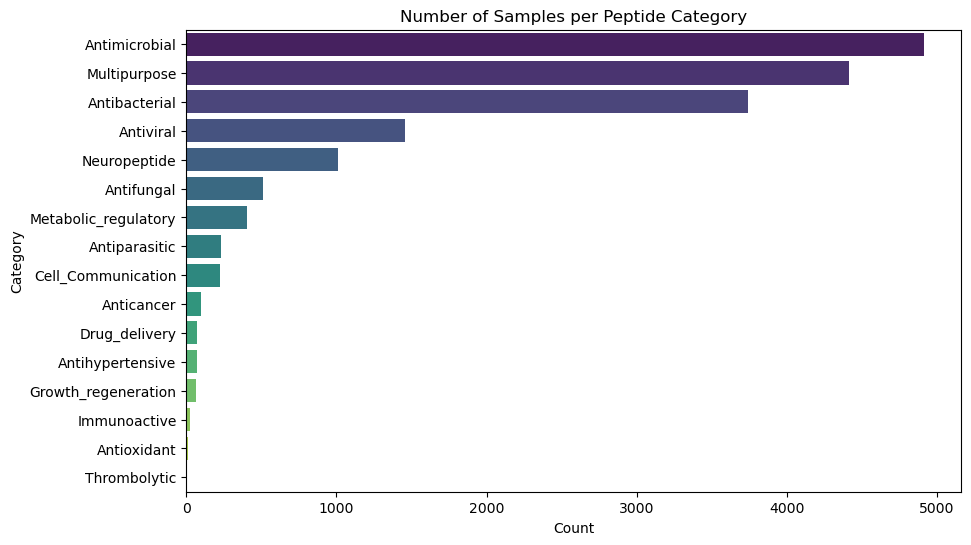

In [7]:
# 1. Get the exact counts
category_counts = labels['MAIN_Category'].value_counts()
print(category_counts)

# 2. Visualize the distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')
plt.title('Number of Samples per Peptide Category')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

In [25]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# It is best practice to scale data before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(embeddings_finetuned)

# Keep 95% of the variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"Original dimensions: {X_scaled.shape[1]}")
print(f"Reduced dimensions: {X_pca.shape[1]}")

Original dimensions: 200
Reduced dimensions: 14


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Encode string labels into numbers
le = LabelEncoder()
y_main = le.fit_transform(labels['MAIN_Category'])

# Split the data (stratify ensures proportional class representation in the test set)
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y_main, test_size=0.2, random_state=42, stratify=y_main
)

# Initialize model with 'balanced' class weights to handle your imbalanced data
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


                      precision    recall  f1-score   support

       Antibacterial       0.69      0.74      0.71       748
          Anticancer       1.00      0.10      0.18        20
          Antifungal       0.86      0.70      0.77       102
    Antihypertensive       0.00      0.00      0.00        15
       Antimicrobial       0.83      0.87      0.85       983
         Antioxidant       0.00      0.00      0.00         3
       Antiparasitic       0.84      0.59      0.69        46
           Antiviral       0.92      0.82      0.87       292
  Cell_Communication       0.86      0.27      0.41        45
       Drug_delivery       1.00      0.20      0.33        15
 Growth_regeneration       0.50      0.08      0.13        13
        Immunoactive       1.00      0.60      0.75         5
Metabolic_regulatory       0.81      0.63      0.71        81
        Multipurpose       0.64      0.63      0.63       882
        Neuropeptide       0.64      0.86      0.73       202
       

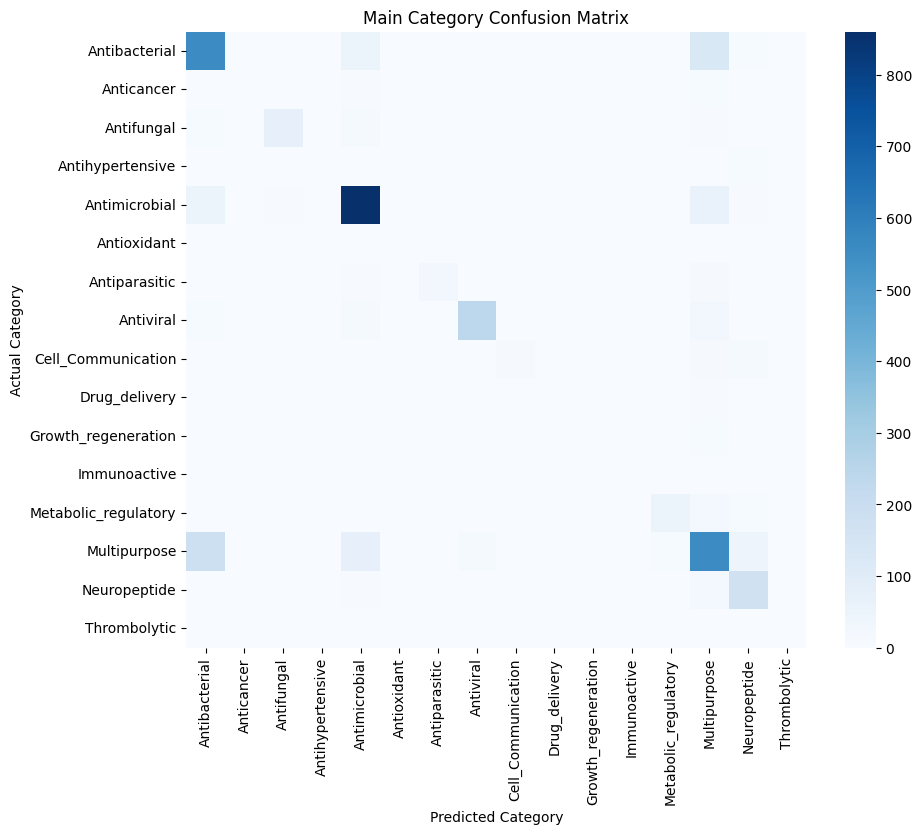

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = rf_model.predict(X_test)

# 1. Print detailed text metrics
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

# 2. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.title('Main Category Confusion Matrix')
plt.show()

In [25]:
# all the main categories are within columns (containing main + subcategories)
# here I select df to contain only main categories, where 'Multipurpose' peptides will have multiple labels
# train decision tree for multilabel prediction


cats = list(labels.MAIN_Category.unique())
cats.remove('Multipurpose')
print(cats)

labels_main_multicat = labels.loc[:, cats]

print(embeddings_finetuned.shape)
print(labels_main_multicat.shape)

# sum labels in each category 
labels_sum = labels_main_multicat.sum(axis=0)

# remove labels accounting to <1% of dataset
labels_to_keep = labels_sum[labels_sum >= sum(labels_sum)*0.01]
print(labels_to_keep.index)

labels_main_multicat = labels_main_multicat.loc[:, labels_to_keep.index]
print(labels_main_multicat.shape)
print(labels_main_multicat.head())

['Antibacterial', 'Metabolic_regulatory', 'Antimicrobial', 'Anticancer', 'Growth_regeneration', 'Antiviral', 'Cell_Communication', 'Neuropeptide', 'Drug_delivery', 'Antihypertensive', 'Antifungal', 'Antiparasitic', 'Antioxidant', 'Thrombolytic', 'Immunoactive']
(17265, 200)
(17265, 15)
Index(['Antibacterial', 'Metabolic_regulatory', 'Antimicrobial', 'Anticancer',
       'Antiviral', 'Cell_Communication', 'Neuropeptide', 'Antifungal',
       'Antiparasitic'],
      dtype='object')
(17265, 9)
        Antibacterial  Metabolic_regulatory  Antimicrobial  Anticancer  \
ID                                                                       
100004              1                     0              0           0   
100007              1                     0              0           0   
100013              1                     0              0           0   
100014              1                     0              0           0   
100015              1                     0              0  

Decision Tree Accuracy: 0.5543541224174551
Classification Report:               precision    recall  f1-score   support

           0       0.87      0.88      0.87      2088
           1       0.68      0.70      0.69       191
           2       0.84      0.79      0.82      1652
           3       0.61      0.15      0.24       422
           4       0.89      0.49      0.63       771
           5       0.54      0.38      0.45       198
           6       0.64      0.76      0.70       429
           7       0.60      0.43      0.50       910
           8       0.59      0.30      0.40       159

   micro avg       0.79      0.67      0.72      6820
   macro avg       0.70      0.54      0.59      6820
weighted avg       0.78      0.67      0.70      6820
 samples avg       0.74      0.70      0.70      6820



/home/iganiemi/anaconda3/envs/ml-for-molbio/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/iganiemi/anaconda3/envs/ml-for-molbio/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/iganiemi/anaconda3/envs/ml-for-molbio/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(aver

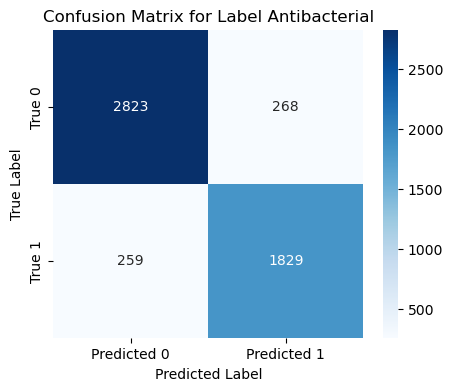

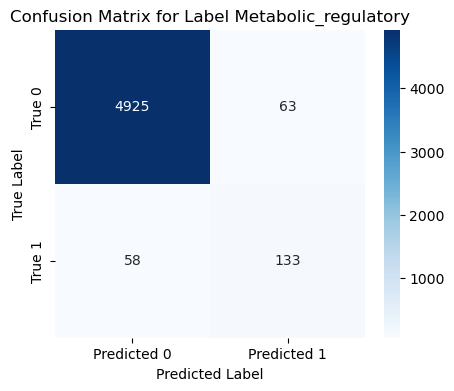

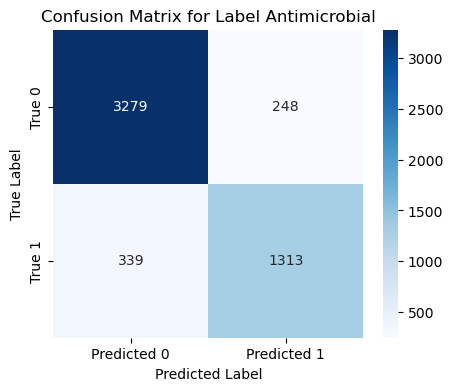

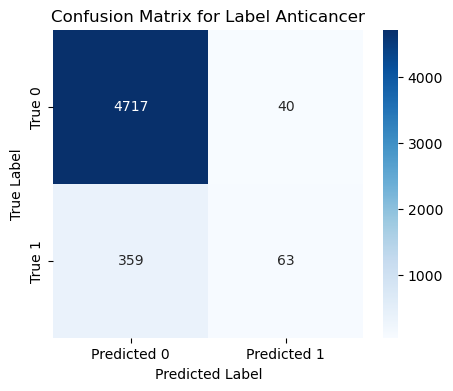

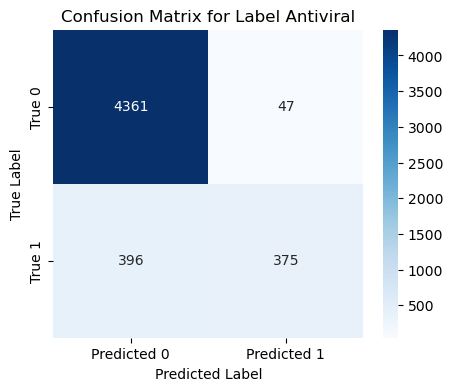

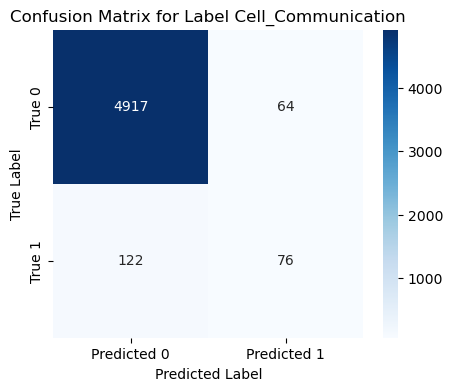

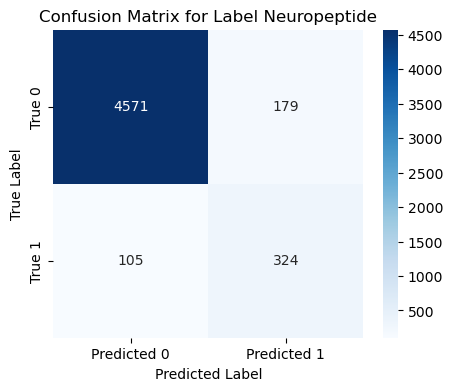

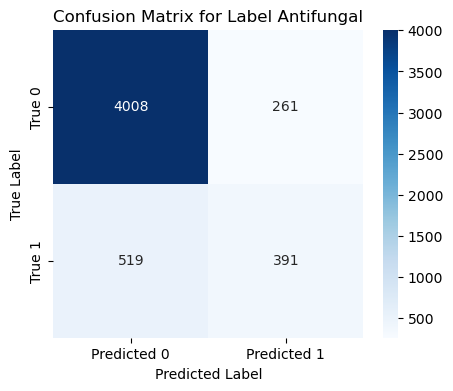

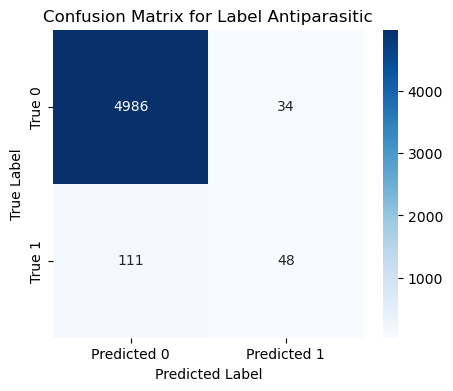

In [28]:
# overall it works ok for main and big categories, but quite shitty for small ones (as expected, always predicts 0)
# works better on full embeddings_finetuned than PCA from them

from sklearn.model_selection import train_test_split
from skmultilearn.model_selection import iterative_train_test_split, IterativeStratification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.svm import SVC
#from imblearn.under_sampling import RandomUnderSampler
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, multilabel_confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

X = embeddings_finetuned
#X = pd.DataFrame(X_pca)
y = labels_main_multicat
#############################
# normal stratification
#X_train, X_test, y_train, y_test = train_test_split(embeddings_finetuned, labels_main_multicat, test_size=0.3, random_state=42)

############################
# alternative stratification for multiclass
stratifier = IterativeStratification(n_splits=2, order=1, sample_distribution_per_fold=[0.3, 0.7, ])
train_indices, test_indices = next(stratifier.split(X, y))
X_train, y_train = X.iloc[train_indices, :], y.iloc[train_indices, :]
X_test, y_test = X.iloc[test_indices, :], y.iloc[test_indices, :]

############################
# alternative random undersampling of frequent classes

# rus = RandomUnderSampler()
# X_train, y_train = rus.fit_resample(X_train, y_train)
###########################

# make classifier
#dtree = DecisionTreeClassifier(max_depth=6, random_state=42) # acc 0.53
dtree = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # acc 0.63
#dtree = BaggingClassifier() # acc 0.58, super slow
#dtree = SVC(kernel='rbf', C=1, random_state=42) # acc 0.62


dtree_multi = MultiOutputClassifier(dtree)
dtree_multi.fit(X_train, y_train)
dtree_preds = dtree_multi.predict(X_test)
dtree_acc = accuracy_score(y_test, dtree_preds)
dtree_cm = multilabel_confusion_matrix(y_test, dtree_preds)
dtree_cr = classification_report(y_test, dtree_preds)

print("Decision Tree Accuracy:", dtree_acc)

print('Classification Report:', dtree_cr)

# Generate and plot confusion matrices for each label
for i in range(y.shape[1]):  # Iterate through each label
    cm = confusion_matrix(y_test.iloc[:, i], dtree_preds[:, i])
    #cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100 # scaling to show %
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', # fmt=".2f"
                xticklabels=['Predicted 0', 'Predicted 1'], 
                yticklabels=['True 0', 'True 1'])
    plt.title(f'Confusion Matrix for Label {y.columns[i]}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


In [50]:
# check how many labels are within Multicategory - too much to add them as separate labels for prediction..

def label_multicat(row, cats):
    lab = ''
    for cat in cats:
        if row[cat] == 1 and not np.isnan(row[cat]):
            lab = lab + '_' + cat
    if lab == '':
        lab = 'Undefined'
    else:
        lab = lab.removeprefix('_')
    return(lab)

cats_list = list(labels.MAIN_Category.unique())
cats_list.remove('Multipurpose')
print(cats_list)

labels_main_multicat = labels.loc[:, ['MAIN_Category', 'isSinglepurpose'] + cats_list]
labels_main_multicat.head()

multi = labels_main_multicat.loc[labels_main_multicat.MAIN_Category == 'Multipurpose', :]
multi['MAIN_Category2'] = multi.apply(label_multicat, axis=1, cats = cats_list)

print(multi.head())
print(multi['MAIN_Category2'].value_counts())

(17265, 200)
(17265, 17)
['Antibacterial', 'Metabolic_regulatory', 'Antimicrobial', 'Anticancer', 'Growth_regeneration', 'Antiviral', 'Cell_Communication', 'Neuropeptide', 'Drug_delivery', 'Antihypertensive', 'Antifungal', 'Antiparasitic', 'Antioxidant', 'Thrombolytic', 'Immunoactive']
       MAIN_Category  isSinglepurpose  Antibacterial  Metabolic_regulatory  \
ID                                                                           
100013  Multipurpose            False              1                     0   
100014  Multipurpose            False              1                     0   
100015  Multipurpose            False              1                     0   
100016  Multipurpose            False              1                     0   
100017  Multipurpose            False              1                     0   

        Antimicrobial  Anticancer  Growth_regeneration  Antiviral  \
ID                                                                  
100013              0       

/tmp/ipykernel_277506/133028865.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  multi['MAIN_Category2'] = multi.apply(label_multicat, axis=1, cats = cats_list)
